# Smart City Sensor Readings: NumPy, Pandas and Visualization Project

This beginner-friendly project uses a real sensor dataset to practice the core data-analysis skills needed for data science, analytics and quantitative roles.

## What this notebook covers

1. NumPy arrays, attributes, data types, indexing, slicing, arithmetic and logical operations  
2. Pandas DataFrame basics: loading, inspecting, creating columns, deleting columns, sorting and filtering  
3. Conditional counting and boolean masking  
4. GroupBy analysis and aggregation  
5. Matplotlib plots: line plot, scatter plot, histogram and bar plot  
6. Seaborn plots: scatterplot with hue, count plot, bar plot, box plot and heatmap  
7. A small end-to-end exploratory data analysis workflow

Dataset: `Sensor_readings.csv`

In [2]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 4.3 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Import libraries

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Optional plot style
sns.set_theme(style="whitegrid")

## 2. Load the data

In [4]:
df = pd.read_csv("Sensor_readings.csv")

df.head()

,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,humidity_min,humidity_max,humidity_avg,model,latitude,longitude,elevation,location,rowid,position,geolocation
0,2015-03-23T09:55:00+00:00,0013a20040b315ec,1,501,16.5,16.5,16.5,1.1,1.1,1.1,73.8,73.8,73.8,ENV,-37.814808,144.980999,29.96,Fitzroy Gardens,501-20150323095500,NaN,"-37.8148084, 144.980999"
1,2015-03-23T10:10:00+00:00,0013a20040b516ed,1,505,17.7,17.7,17.7,2.9,2.9,2.9,59.2,59.2,59.2,ENV,-37.813073,144.980406,29.91,Fitzroy Gardens,505-20150323101000,NaN,"-37.813073, 144.9804061"
2,2015-03-23T10:35:00+00:00,0013a20040b31583,1,509,17.4,17.4,17.4,3.1,3.1,3.1,63.6,63.6,63.6,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150323103500,NaN,"-37.8199043, 144.9404851"
3,2015-03-23T14:55:00+00:00,0013a20040b3155c,1,506,14.2,14.2,14.2,8.5,8.5,8.5,57.8,57.8,57.8,ENV,-37.820354,144.940482,0.71,Docklands Library,506-20150323145500,NaN,"-37.8203537, 144.9404816"
4,2015-03-23T23:05:00+00:00,0013a20040b31583,1,509,14.8,14.8,14.8,90.6,90.6,90.6,49.1,49.1,49.1,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150323230500,NaN,"-37.8199043, 144.9404851"


In [5]:
print("Rows and columns:", df.shape)
df.info()

Rows and columns: (56570, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56570 entries, 0 to 56569
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     56570 non-null  object 
 1   mac           56570 non-null  object 
 2   boardtype     56570 non-null  int64  
 3   boardid       56570 non-null  int64  
 4   temp_max      56570 non-null  float64
 5   temp_min      56570 non-null  float64
 6   temp_avg      56570 non-null  float64
 7   light_max     56570 non-null  float64
 8   light_min     56570 non-null  float64
 9   light_avg     56570 non-null  float64
 10  humidity_min  56570 non-null  float64
 11  humidity_max  56570 non-null  float64
 12  humidity_avg  56570 non-null  float64
 13  model         56570 non-null  object 
 14  latitude      56570 non-null  float64
 15  longitude     56570 non-null  float64
 16  elevation     34975 non-null  float64
 17  location      56570 non-null  object 
 

## 3. Quick dataset overview

We inspect column names, missing values, duplicate rows and basic summary statistics.

In [6]:
df.columns

Index(['timestamp', 'mac', 'boardtype', 'boardid', 'temp_max', 'temp_min', 'temp_avg', 'light_max', 'light_min',
       'light_avg', 'humidity_min', 'humidity_max', 'humidity_avg', 'model', 'latitude', 'longitude', 'elevation',
       'location', 'rowid', 'position', 'geolocation'],
      dtype='object')

In [7]:
df.isna().sum().sort_values(ascending=False)

position        56570
elevation       21595
timestamp           0
humidity_max        0
rowid               0
location            0
longitude           0
latitude            0
model               0
humidity_avg        0
humidity_min        0
mac                 0
light_avg           0
light_min           0
light_max           0
temp_avg            0
temp_min            0
temp_max            0
boardid             0
boardtype           0
geolocation         0
dtype: int64

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
boardtype,56570.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
boardid,56570.0,507.918738,2.673337,501.000000,506.000000,509.000000,510.000000,511.000000
temp_max,56570.0,18.522650,5.498701,4.200000,14.800000,17.700000,21.900000,45.200000
temp_min,56570.0,18.522650,5.498701,4.200000,14.800000,17.700000,21.900000,45.200000
temp_avg,56570.0,18.522650,5.498701,4.200000,14.800000,17.700000,21.900000,45.200000
light_max,56570.0,48.674527,43.973493,0.000000,2.900000,49.900000,94.900000,98.700000
light_min,56570.0,48.674527,43.973493,0.000000,2.900000,49.900000,94.900000,98.700000
light_avg,56570.0,48.674527,43.973493,0.000000,2.900000,49.900000,94.900000,98.700000
humidity_min,56570.0,49.431043,13.413633,-24.900000,41.700000,51.000000,58.700000,102.500000
humidity_max,56570.0,49.431043,13.413633,-24.900000,41.700000,51.000000,58.700000,102.500000


## 4. NumPy basics using the sensor data

A Pandas column can be converted to a NumPy array. This helps understand the connection between Pandas and NumPy.

In [10]:
temp = df["temp_avg"].to_numpy()
humidity = df["humidity_avg"].to_numpy()
light = df["light_avg"].to_numpy()

print(type(temp))
print("Shape:", temp.shape)
print("Number of dimensions:", temp.ndim)
print("Number of elements:", temp.size)
print("Data type:", temp.dtype)
print("Memory in bytes:", temp.nbytes)

<class 'numpy.ndarray'>
Shape: (56570,)
Number of dimensions: 1
Number of elements: 56570
Data type: float64
Memory in bytes: 452560


### 4.1 NumPy indexing and slicing

In [11]:
print("First temperature value:", temp[0])
print("Last temperature value:", temp[-1])
print("First five temperature values:", temp[:5])
print("Every 10000th temperature value:", temp[::10000])

First temperature value: 16.5
Last temperature value: 16.5
First five temperature values: [16.5 17.7 17.4 14.2 14.8]
Every 10000th temperature value: [16.5 13.5 23.9 23.9 16.1 15.5]


### 4.2 NumPy arithmetic operations

In [14]:
# Convert Celsius to Fahrenheit
temp_fahrenheit = temp * 9/5 + 32

print("First five Celsius values:", temp[:5])
print("First five Fahrenheit values:", temp_fahrenheit[:5])

First five Celsius values: [16.5 17.7 17.4 14.2 14.8]
First five Fahrenheit values: [61.7  63.86 63.32 57.56 58.64]


In [15]:
# Difference between max and min temperature readings
temp_range = df["temp_max"].to_numpy() - df["temp_min"].to_numpy()

print("Average temperature range:", temp_range.mean())
print("Maximum temperature range:", temp_range.max())

Average temperature range: 0.0
Maximum temperature range: 0.0


### 4.3 NumPy mathematical functions

In [16]:
print("Mean temperature:", np.mean(temp))
print("Median temperature:", np.median(temp))
print("Minimum temperature:", np.min(temp))
print("Maximum temperature:", np.max(temp))
print("Standard deviation:", np.std(temp))

Mean temperature: 18.52264981438925
Median temperature: 17.7
Minimum temperature: 4.2
Maximum temperature: 45.2
Standard deviation: 5.498652748989102


### 4.4 NumPy logical functions and conditional counting

In [17]:
hot_mask = temp > 30
humid_mask = humidity > 70

print("Any temperature above 30 C?", np.any(hot_mask))
print("Are all temperatures above 0 C?", np.all(temp > 0))
print("Number of readings above 30 C:", np.count_nonzero(hot_mask))
print("Number of readings with humidity above 70%:", humid_mask.sum())

Any temperature above 30 C? True
Are all temperatures above 0 C? True
Number of readings above 30 C: 1969
Number of readings with humidity above 70%: 725


### 4.5 Boolean masking with NumPy

Boolean masking selects only values that satisfy a condition.

In [18]:
hot_temperatures = temp[temp > 30]

print("Number of hot readings:", len(hot_temperatures))
print("First 10 hot readings:", hot_temperatures[:10])

Number of hot readings: 1969
First 10 hot readings: [30.3 32.6 30.6 31.3 32.6 30.3 30.3 31.6 32.3 31. ]


## 5. Pandas cleaning and feature engineering

We create a working copy so the original data remains unchanged.

In [19]:
data = df.copy()
data.head()

,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,humidity_min,humidity_max,humidity_avg,model,latitude,longitude,elevation,location,rowid,position,geolocation
0,2015-03-23T09:55:00+00:00,0013a20040b315ec,1,501,16.5,16.5,16.5,1.1,1.1,1.1,73.8,73.8,73.8,ENV,-37.814808,144.980999,29.96,Fitzroy Gardens,501-20150323095500,NaN,"-37.8148084, 144.980999"
1,2015-03-23T10:10:00+00:00,0013a20040b516ed,1,505,17.7,17.7,17.7,2.9,2.9,2.9,59.2,59.2,59.2,ENV,-37.813073,144.980406,29.91,Fitzroy Gardens,505-20150323101000,NaN,"-37.813073, 144.9804061"
2,2015-03-23T10:35:00+00:00,0013a20040b31583,1,509,17.4,17.4,17.4,3.1,3.1,3.1,63.6,63.6,63.6,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150323103500,NaN,"-37.8199043, 144.9404851"
3,2015-03-23T14:55:00+00:00,0013a20040b3155c,1,506,14.2,14.2,14.2,8.5,8.5,8.5,57.8,57.8,57.8,ENV,-37.820354,144.940482,0.71,Docklands Library,506-20150323145500,NaN,"-37.8203537, 144.9404816"
4,2015-03-23T23:05:00+00:00,0013a20040b31583,1,509,14.8,14.8,14.8,90.6,90.6,90.6,49.1,49.1,49.1,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150323230500,NaN,"-37.8199043, 144.9404851"


### 5.1 Convert timestamp to datetime

In [20]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

data["date"] = data["timestamp"].dt.date
data["hour"] = data["timestamp"].dt.hour
data["day_name"] = data["timestamp"].dt.day_name()
data["month"] = data["timestamp"].dt.month_name()

data[["timestamp", "date", "hour", "day_name", "month"]].head()

,timestamp,date,hour,day_name,month
0,2015-03-23 09:55:00+00:00,2015-03-23,9,Monday,March
1,2015-03-23 10:10:00+00:00,2015-03-23,10,Monday,March
2,2015-03-23 10:35:00+00:00,2015-03-23,10,Monday,March
3,2015-03-23 14:55:00+00:00,2015-03-23,14,Monday,March
4,2015-03-23 23:05:00+00:00,2015-03-23,23,Monday,March


### 5.2 Create new columns

Examples:
- `temp_range`: difference between maximum and minimum temperature
- `humidity_range`: difference between maximum and minimum humidity
- `light_range`: difference between maximum and minimum light
- `temp_category`: low, medium, high temperature groups

In [21]:
data["temp_range"] = data["temp_max"] - data["temp_min"]
data["humidity_range"] = data["humidity_max"] - data["humidity_min"]
data["light_range"] = data["light_max"] - data["light_min"]

data["temp_category"] = pd.cut(
    data["temp_avg"],
    bins=[-np.inf, 15, 25, np.inf],
    labels=["low", "medium", "high"]
)

data[["temp_avg", "temp_range", "humidity_avg", "humidity_range", "light_avg", "light_range", "temp_category"]].head()

,temp_avg,temp_range,humidity_avg,humidity_range,light_avg,light_range,temp_category
0,16.5,0.0,73.8,0.0,1.1,0.0,medium
1,17.7,0.0,59.2,0.0,2.9,0.0,medium
2,17.4,0.0,63.6,0.0,3.1,0.0,medium
3,14.2,0.0,57.8,0.0,8.5,0.0,low
4,14.8,0.0,49.1,0.0,90.6,0.0,low


### 5.3 Delete or drop columns

Some columns are not useful for basic analysis:
- `position` is fully missing
- `rowid` is just an identifier
- `model` has only one value

In [22]:
columns_to_drop = ["position", "rowid", "model"]

data_small = data.drop(columns=columns_to_drop)

print("Original shape:", data.shape)
print("After dropping columns:", data_small.shape)
data_small.head()

Original shape: (56570, 29)
After dropping columns: (56570, 26)


,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,humidity_min,humidity_max,humidity_avg,latitude,longitude,elevation,location,geolocation,date,hour,day_name,month,temp_range,humidity_range,light_range,temp_category
0,2015-03-23 09:55:00+00:00,0013a20040b315ec,1,501,16.5,16.5,16.5,1.1,1.1,1.1,73.8,73.8,73.8,-37.814808,144.980999,29.96,Fitzroy Gardens,"-37.8148084, 144.980999",2015-03-23,9,Monday,March,0.0,0.0,0.0,medium
1,2015-03-23 10:10:00+00:00,0013a20040b516ed,1,505,17.7,17.7,17.7,2.9,2.9,2.9,59.2,59.2,59.2,-37.813073,144.980406,29.91,Fitzroy Gardens,"-37.813073, 144.9804061",2015-03-23,10,Monday,March,0.0,0.0,0.0,medium
2,2015-03-23 10:35:00+00:00,0013a20040b31583,1,509,17.4,17.4,17.4,3.1,3.1,3.1,63.6,63.6,63.6,-37.819904,144.940485,0.03,Docklands Library,"-37.8199043, 144.9404851",2015-03-23,10,Monday,March,0.0,0.0,0.0,medium
3,2015-03-23 14:55:00+00:00,0013a20040b3155c,1,506,14.2,14.2,14.2,8.5,8.5,8.5,57.8,57.8,57.8,-37.820354,144.940482,0.71,Docklands Library,"-37.8203537, 144.9404816",2015-03-23,14,Monday,March,0.0,0.0,0.0,low
4,2015-03-23 23:05:00+00:00,0013a20040b31583,1,509,14.8,14.8,14.8,90.6,90.6,90.6,49.1,49.1,49.1,-37.819904,144.940485,0.03,Docklands Library,"-37.8199043, 144.9404851",2015-03-23,23,Monday,March,0.0,0.0,0.0,low


## 6. Sorting DataFrames

In [23]:
# Highest temperature readings
data.sort_values("temp_avg", ascending=False).head(10)

,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,humidity_min,humidity_max,humidity_avg,model,latitude,longitude,elevation,location,rowid,position,geolocation,date,hour,day_name,month,temp_range,humidity_range,light_range,temp_category
48206,2015-01-02 05:20:00+00:00,0013a20040b31571,1,510,45.2,45.2,45.2,98.2,98.2,98.2,20.9,20.9,20.9,ENV,-37.819712,144.941325,NaN,Docklands Library,510-20150102052000,NaN,"-37.8197121, 144.9413253",2015-01-02,5,Friday,January,0.0,0.0,0.0,high
5625,2015-01-02 05:20:00+00:00,0013a20040b5b337,1,511,43.9,43.9,43.9,98.6,98.6,98.6,11.7,11.7,11.7,ENV,-37.819500,144.941889,NaN,Docklands Library,511-20150102052000,NaN,"-37.8195002, 144.9418888",2015-01-02,5,Friday,January,0.0,0.0,0.0,high
7460,2015-02-15 07:00:00+00:00,0013a20040b31571,1,510,43.2,43.2,43.2,98.3,98.3,98.3,28.6,28.6,28.6,ENV,-37.819712,144.941325,NaN,Docklands Library,510-20150215070000,NaN,"-37.8197121, 144.9413253",2015-02-15,7,Sunday,February,0.0,0.0,0.0,high
29296,2015-02-06 06:35:00+00:00,0013a20040b31571,1,510,42.9,42.9,42.9,98.2,98.2,98.2,26.7,26.7,26.7,ENV,-37.819712,144.941325,NaN,Docklands Library,510-20150206063500,NaN,"-37.8197121, 144.9413253",2015-02-06,6,Friday,February,0.0,0.0,0.0,high
2927,2015-01-02 06:50:00+00:00,0013a20040b5b337,1,511,42.9,42.9,42.9,97.4,97.4,97.4,10.5,10.5,10.5,ENV,-37.819500,144.941889,NaN,Docklands Library,511-20150102065000,NaN,"-37.8195002, 144.9418888",2015-01-02,6,Friday,January,0.0,0.0,0.0,high
30603,2015-01-02 05:20:00+00:00,0013a20040b3155c,1,506,42.6,42.6,42.6,97.8,97.8,97.8,7.5,7.5,7.5,ENV,-37.820354,144.940482,NaN,Docklands Library,506-20150102052000,NaN,"-37.8203537, 144.9404816",2015-01-02,5,Friday,January,0.0,0.0,0.0,high
30602,2015-01-02 04:50:00+00:00,0013a20040b31571,1,510,42.3,42.3,42.3,98.1,98.1,98.1,20.7,20.7,20.7,ENV,-37.819712,144.941325,NaN,Docklands Library,510-20150102045000,NaN,"-37.8197121, 144.9413253",2015-01-02,4,Friday,January,0.0,0.0,0.0,high
43192,2015-02-06 07:05:00+00:00,0013a20040b31571,1,510,42.3,42.3,42.3,98.2,98.2,98.2,28.0,28.0,28.0,ENV,-37.819712,144.941325,NaN,Docklands Library,510-20150206070500,NaN,"-37.8197121, 144.9413253",2015-02-06,7,Friday,February,0.0,0.0,0.0,high
16484,2015-02-06 06:55:00+00:00,0013a20040b31571,1,510,42.3,42.3,42.3,98.2,98.2,98.2,27.6,27.6,27.6,ENV,-37.819712,144.941325,NaN,Docklands Library,510-20150206065500,NaN,"-37.8197121, 144.9413253",2015-02-06,6,Friday,February,0.0,0.0,0.0,high
51561,2015-01-02 06:25:00+00:00,0013a20040b31571,1,510,41.9,41.9,41.9,98.2,98.2,98.2,19.6,19.6,19.6,ENV,-37.819712,144.941325,NaN,Docklands Library,510-20150102062500,NaN,"-37.8197121, 144.9413253",2015-01-02,6,Friday,January,0.0,0.0,0.0,high


In [24]:
# Sort by location and timestamp
data.sort_values(["location", "timestamp"]).head()

,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,humidity_min,humidity_max,humidity_avg,model,latitude,longitude,elevation,location,rowid,position,geolocation,date,hour,day_name,month,temp_range,humidity_range,light_range,temp_category
12607,2014-12-15 03:55:00+00:00,0013a20040b3155c,1,506,23.5,23.5,23.5,94.8,94.8,94.8,44.5,44.5,44.5,ENV,-37.820354,144.940482,NaN,Docklands Library,506-20141215035500,NaN,"-37.8203537, 144.9404816",2014-12-15,3,Monday,December,0.0,0.0,0.0,medium
12608,2014-12-15 03:55:00+00:00,0013a20040b5b337,1,511,23.5,23.5,23.5,96.3,96.3,96.3,43.1,43.1,43.1,ENV,-37.819500,144.941889,NaN,Docklands Library,511-20141215035500,NaN,"-37.8195002, 144.9418888",2014-12-15,3,Monday,December,0.0,0.0,0.0,medium
23149,2014-12-15 04:00:00+00:00,0013a20040b31571,1,510,24.2,24.2,24.2,97.6,97.6,97.6,43.4,43.4,43.4,ENV,-37.819712,144.941325,NaN,Docklands Library,510-20141215040000,NaN,"-37.8197121, 144.9413253",2014-12-15,4,Monday,December,0.0,0.0,0.0,medium
44323,2014-12-15 04:00:00+00:00,0013a20040b31583,1,509,22.9,22.9,22.9,97.8,97.8,97.8,46.6,46.6,46.6,ENV,-37.819904,144.940485,NaN,Docklands Library,509-20141215040000,NaN,"-37.8199043, 144.9404851",2014-12-15,4,Monday,December,0.0,0.0,0.0,medium
17234,2014-12-15 04:05:00+00:00,0013a20040b3155c,1,506,24.5,24.5,24.5,98.2,98.2,98.2,44.5,44.5,44.5,ENV,-37.820354,144.940482,NaN,Docklands Library,506-20141215040500,NaN,"-37.8203537, 144.9404816",2014-12-15,4,Monday,December,0.0,0.0,0.0,medium


## 7. Filtering DataFrames

Filtering is one of the most important Pandas skills.

In [25]:
# Readings from Docklands Library only
docklands = data[data["location"] == "Docklands Library"]

docklands.head()

,timestamp,mac,boardtype,boardid,temp_max,temp_min,temp_avg,light_max,light_min,light_avg,humidity_min,humidity_max,humidity_avg,model,latitude,longitude,elevation,location,rowid,position,geolocation,date,hour,day_name,month,temp_range,humidity_range,light_range,temp_category
2,2015-03-23 10:35:00+00:00,0013a20040b31583,1,509,17.4,17.4,17.4,3.1,3.1,3.1,63.6,63.6,63.6,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150323103500,NaN,"-37.8199043, 144.9404851",2015-03-23,10,Monday,March,0.0,0.0,0.0,medium
3,2015-03-23 14:55:00+00:00,0013a20040b3155c,1,506,14.2,14.2,14.2,8.5,8.5,8.5,57.8,57.8,57.8,ENV,-37.820354,144.940482,0.71,Docklands Library,506-20150323145500,NaN,"-37.8203537, 144.9404816",2015-03-23,14,Monday,March,0.0,0.0,0.0,low
4,2015-03-23 23:05:00+00:00,0013a20040b31583,1,509,14.8,14.8,14.8,90.6,90.6,90.6,49.1,49.1,49.1,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150323230500,NaN,"-37.8199043, 144.9404851",2015-03-23,23,Monday,March,0.0,0.0,0.0,low
5,2015-03-24 06:20:00+00:00,0013a20040b31571,1,510,14.5,14.5,14.5,91.1,91.1,91.1,44.8,44.8,44.8,ENV,-37.819712,144.941325,2.74,Docklands Library,510-20150324062000,NaN,"-37.8197121, 144.9413253",2015-03-24,6,Tuesday,March,0.0,0.0,0.0,low
6,2015-03-23 20:00:00+00:00,0013a20040b31583,1,509,13.9,13.9,13.9,2.6,2.6,2.6,61.7,61.7,61.7,ENV,-37.819904,144.940485,0.03,Docklands Library,509-20150323200000,NaN,"-37.8199043, 144.9404851",2015-03-23,20,Monday,March,0.0,0.0,0.0,low


In [26]:
# Hot and humid readings
hot_humid = data[(data["temp_avg"] > 30) & (data["humidity_avg"] > 60)]

hot_humid[["timestamp", "location", "temp_avg", "humidity_avg", "light_avg"]].head()

,timestamp,location,temp_avg,humidity_avg,light_avg


In [27]:
# Morning readings
morning = data[(data["hour"] >= 6) & (data["hour"] < 12)]

morning[["timestamp", "hour", "location", "temp_avg"]].head()

,timestamp,hour,location,temp_avg
0,2015-03-23 09:55:00+00:00,9,Fitzroy Gardens,16.5
1,2015-03-23 10:10:00+00:00,10,Fitzroy Gardens,17.7
2,2015-03-23 10:35:00+00:00,10,Docklands Library,17.4
5,2015-03-24 06:20:00+00:00,6,Docklands Library,14.5
11,2015-03-24 06:45:00+00:00,6,Docklands Library,15.2


## 8. Conditional counting in Pandas

In [28]:
print("Readings above 30 C:", (data["temp_avg"] > 30).sum())
print("Readings with light above 90:", (data["light_avg"] > 90).sum())
print("Readings with humidity below 40:", (data["humidity_avg"] < 40).sum())

Readings above 30 C: 1969
Readings with light above 90: 21768
Readings with humidity below 40: 12237


In [29]:
# Count by temperature category
data["temp_category"].value_counts()

temp_category
medium    34407
low       15380
high       6783
Name: count, dtype: int64

## 9. GroupBy analysis

GroupBy lets us summarize data by categories such as location, board ID, hour or month.

In [30]:
location_summary = data.groupby("location").agg(
    readings=("temp_avg", "count"),
    mean_temp=("temp_avg", "mean"),
    max_temp=("temp_avg", "max"),
    mean_humidity=("humidity_avg", "mean"),
    mean_light=("light_avg", "mean")
).reset_index()

location_summary

,location,readings,mean_temp,max_temp,mean_humidity,mean_light
0,Docklands Library,42381,18.094958,45.2,50.355846,46.782945
1,Fitzroy Gardens,14189,19.800120,37.1,46.668757,54.324477


In [31]:
hourly_summary = data.groupby("hour").agg(
    mean_temp=("temp_avg", "mean"),
    mean_humidity=("humidity_avg", "mean"),
    mean_light=("light_avg", "mean")
).reset_index()

hourly_summary.head()

,hour,mean_temp,mean_humidity,mean_light
0,0,20.685493,44.465083,79.242921
1,1,21.263679,42.886385,81.508057
2,2,21.485907,41.818617,80.882993
3,3,21.778755,40.698197,81.175622
4,4,21.762018,41.350895,76.838416


In [32]:
board_summary = data.groupby("boardid").agg(
    readings=("temp_avg", "count"),
    mean_temp=("temp_avg", "mean"),
    mean_humidity=("humidity_avg", "mean"),
    mean_light=("light_avg", "mean")
).sort_values("readings", ascending=False)

board_summary.head()

,readings,mean_temp,mean_humidity,mean_light
boardid,,,,
509,19119,18.177933,53.527318,47.437471
510,12038,18.089234,48.385255,50.297392
506,6626,16.884817,46.118382,36.558950
511,4598,19.508808,48.434145,49.593606
507,2918,19.733825,47.534544,55.153804


## 10. Matplotlib visualizations

### 10.1 Line plot: average temperature by hour

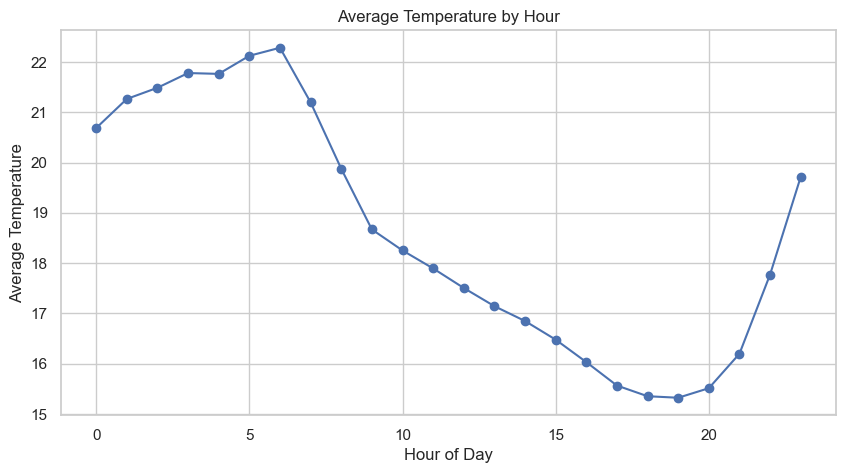

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_summary["hour"], hourly_summary["mean_temp"], marker="o")
plt.title("Average Temperature by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Temperature")
plt.grid(True)
plt.show()

### 10.2 Histogram: temperature distribution

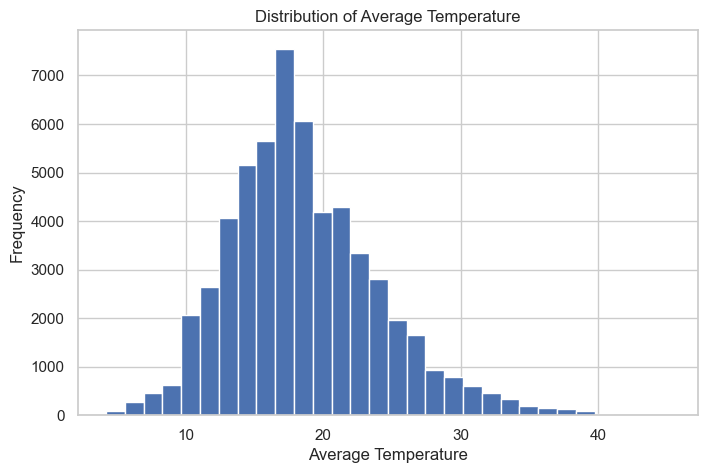

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(data["temp_avg"], bins=30)
plt.title("Distribution of Average Temperature")
plt.xlabel("Average Temperature")
plt.ylabel("Frequency")
plt.show()

### 10.3 Scatter plot: temperature vs humidity

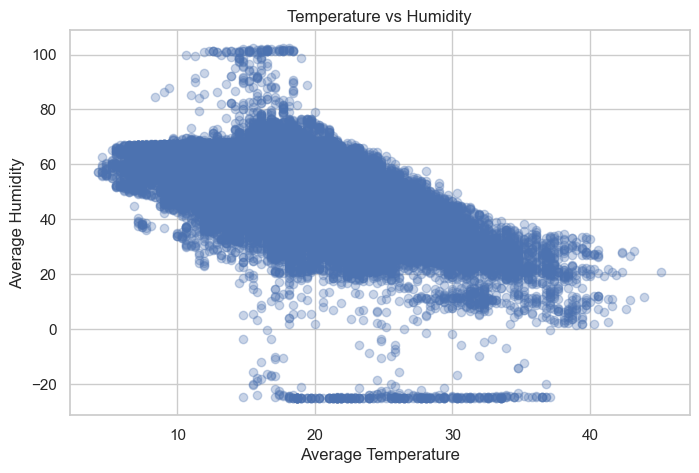

In [35]:
plt.figure(figsize=(8, 5))
plt.scatter(data["temp_avg"], data["humidity_avg"], alpha=0.3)
plt.title("Temperature vs Humidity")
plt.xlabel("Average Temperature")
plt.ylabel("Average Humidity")
plt.show()

### 10.4 Bar plot: average temperature by location

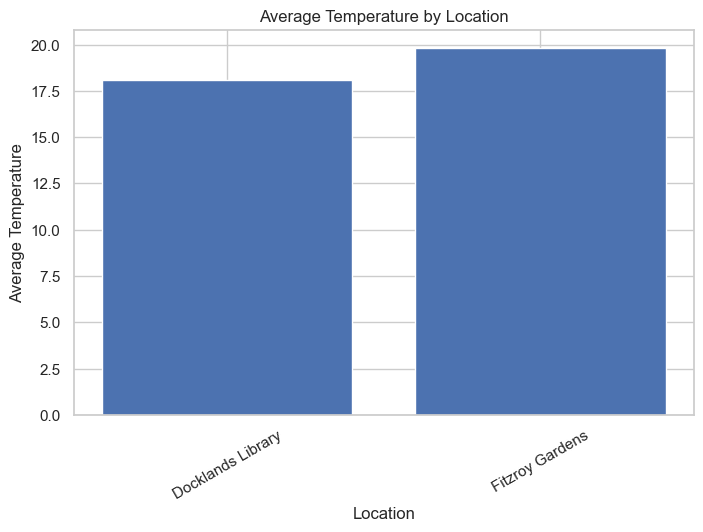

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(location_summary["location"], location_summary["mean_temp"])
plt.title("Average Temperature by Location")
plt.xlabel("Location")
plt.ylabel("Average Temperature")
plt.xticks(rotation=30)
plt.show()

## 11. Seaborn visualizations

### 11.1 Seaborn scatterplot with hue

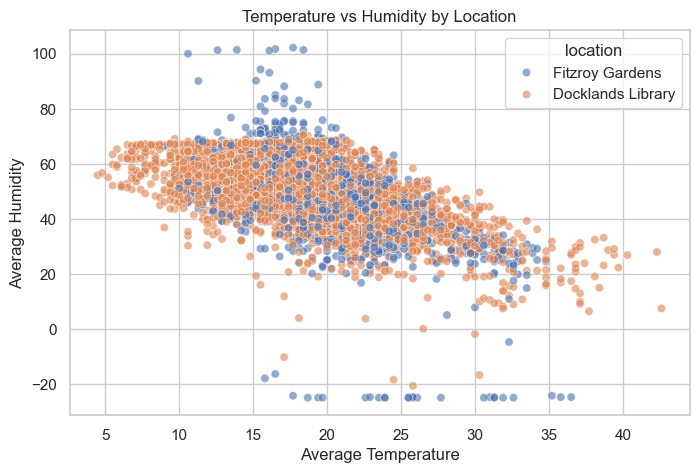

In [37]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=data.sample(5000, random_state=42),
    x="temp_avg",
    y="humidity_avg",
    hue="location",
    alpha=0.6
)
plt.title("Temperature vs Humidity by Location")
plt.xlabel("Average Temperature")
plt.ylabel("Average Humidity")
plt.show()

### 11.2 Count plot

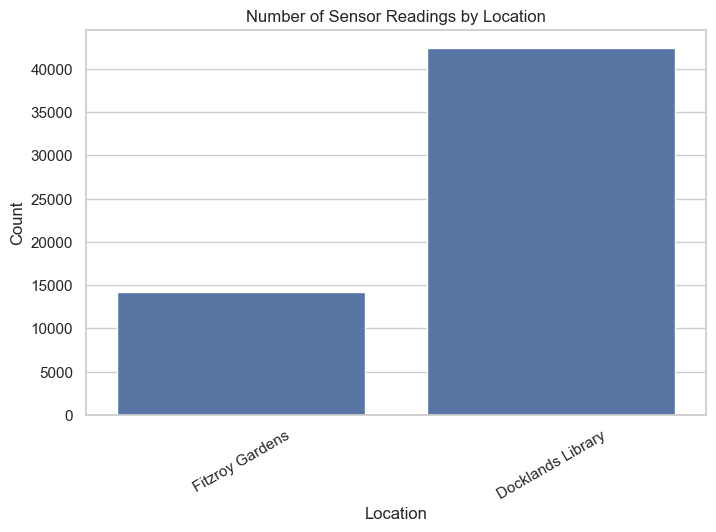

In [38]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="location")
plt.title("Number of Sensor Readings by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

### 11.3 Bar plot

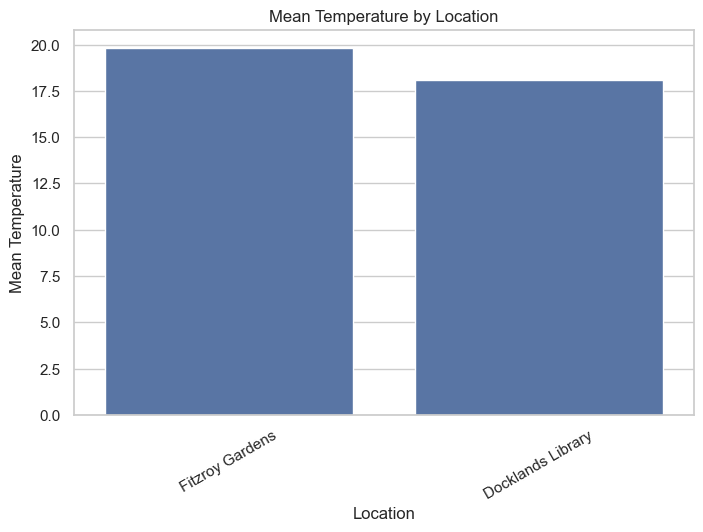

In [39]:
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x="location", y="temp_avg", estimator="mean", errorbar=None)
plt.title("Mean Temperature by Location")
plt.xlabel("Location")
plt.ylabel("Mean Temperature")
plt.xticks(rotation=30)
plt.show()

### 11.4 Box plot

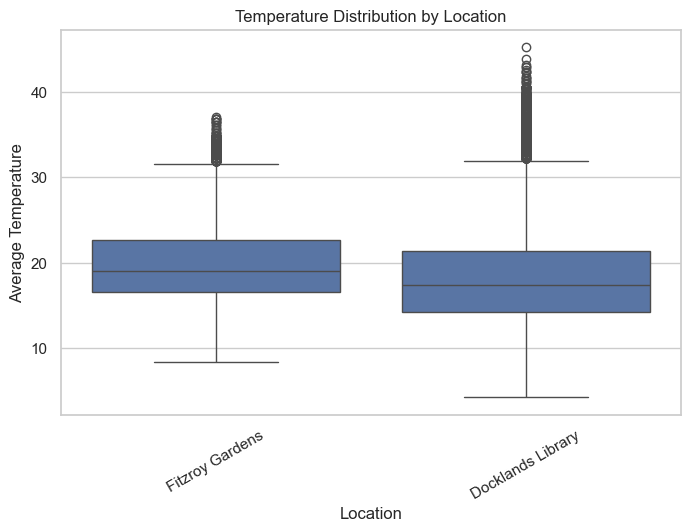

In [40]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="location", y="temp_avg")
plt.title("Temperature Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Average Temperature")
plt.xticks(rotation=30)
plt.show()

### 11.5 Correlation heatmap

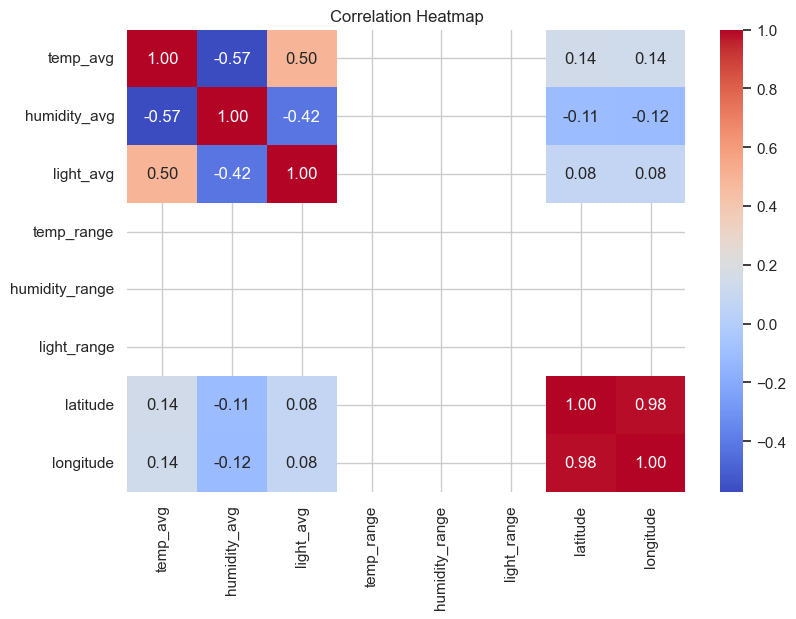

In [41]:
numeric_cols = ["temp_avg", "humidity_avg", "light_avg", "temp_range", "humidity_range", "light_range", "latitude", "longitude"]
corr = data[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 12. Small analytical questions

These examples show how to turn basic Pandas operations into useful insights.

In [42]:
# Which location has the highest average temperature?
location_summary.sort_values("mean_temp", ascending=False)

,location,readings,mean_temp,max_temp,mean_humidity,mean_light
1,Fitzroy Gardens,14189,19.800120,37.1,46.668757,54.324477
0,Docklands Library,42381,18.094958,45.2,50.355846,46.782945


In [43]:
# Which hour is warmest on average?
hourly_summary.sort_values("mean_temp", ascending=False).head()

,hour,mean_temp,mean_humidity,mean_light
6,6,22.281452,42.095331,81.438370
5,5,22.121664,41.178109,79.488602
3,3,21.778755,40.698197,81.175622
4,4,21.762018,41.350895,76.838416
2,2,21.485907,41.818617,80.882993


In [44]:
# Top 10 highest temperature readings
data.nlargest(10, "temp_avg")[["timestamp", "location", "boardid", "temp_avg", "humidity_avg", "light_avg"]]

,timestamp,location,boardid,temp_avg,humidity_avg,light_avg
48206,2015-01-02 05:20:00+00:00,Docklands Library,510,45.2,20.9,98.2
5625,2015-01-02 05:20:00+00:00,Docklands Library,511,43.9,11.7,98.6
7460,2015-02-15 07:00:00+00:00,Docklands Library,510,43.2,28.6,98.3
2927,2015-01-02 06:50:00+00:00,Docklands Library,511,42.9,10.5,97.4
29296,2015-02-06 06:35:00+00:00,Docklands Library,510,42.9,26.7,98.2
30603,2015-01-02 05:20:00+00:00,Docklands Library,506,42.6,7.5,97.8
16484,2015-02-06 06:55:00+00:00,Docklands Library,510,42.3,27.6,98.2
30602,2015-01-02 04:50:00+00:00,Docklands Library,510,42.3,20.7,98.1
43192,2015-02-06 07:05:00+00:00,Docklands Library,510,42.3,28.0,98.2
51561,2015-01-02 06:25:00+00:00,Docklands Library,510,41.9,19.6,98.2


In [45]:
# Top 10 lowest humidity readings
data.nsmallest(10, "humidity_avg")[["timestamp", "location", "boardid", "temp_avg", "humidity_avg", "light_avg"]]

,timestamp,location,boardid,temp_avg,humidity_avg,light_avg
2056,2015-03-22 00:25:00+00:00,Docklands Library,506,27.7,-24.9,95.3
2066,2015-03-22 10:00:00+00:00,Docklands Library,506,24.8,-24.9,8.2
2466,2015-01-20 01:15:00+00:00,Fitzroy Gardens,501,28.1,-24.9,97.1
2470,2015-01-20 02:55:00+00:00,Fitzroy Gardens,501,28.1,-24.9,96.4
2485,2015-01-20 08:25:00+00:00,Fitzroy Gardens,501,27.4,-24.9,91.3
2490,2015-01-20 11:00:00+00:00,Fitzroy Gardens,501,22.3,-24.9,1.0
2496,2015-01-20 10:15:00+00:00,Fitzroy Gardens,501,22.9,-24.9,1.2
2503,2015-01-20 14:55:00+00:00,Fitzroy Gardens,501,20.0,-24.9,1.0
2505,2015-01-20 12:50:00+00:00,Fitzroy Gardens,501,21.0,-24.9,1.0
2513,2015-01-20 16:25:00+00:00,Fitzroy Gardens,501,19.0,-24.9,1.0


## 14. Project summary

In this project, I practiced:

- Creating NumPy arrays from Pandas columns
- NumPy attributes, indexing, slicing, arithmetic and logical operations
- Pandas loading, inspecting, sorting and filtering
- Creating and deleting columns
- Conditional counting
- Boolean masking
- GroupBy aggregation
- Matplotlib line plots, histograms, scatter plots and bar plots
- Seaborn scatterplots with hue, count plots, bar plots, box plots and heatmaps